In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import json
import pandas as pd
import torch
import shutil
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from sklearn.manifold import TSNE
import multiprocessing
import types
from torchvision.models.resnet import Bottleneck
from torch.utils.data import Subset
import numpy as np
import gc

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import requests
from datasets import load_dataset

RESULTS_DIR = Path("/kaggle/working/results")
RESULTS_DIR.mkdir(exist_ok=True)

## Using a Pre-trained ViT for Image Classification

In [ ]:
# We use AutoImageProcessor/AutoModel instead of ViT-specific ones
# to let Hugging Face automatically handle the TIMM integration (ignore this comment, different model used later)
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name, use_fast=True)
model = AutoModelForImageClassification.from_pretrained(model_name, output_attentions=True)

# Select 3 test images
image_urls = {
   "Goldfish": "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01443537_goldfish.JPEG",
    "Box Turtle": "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01669191_box_turtle.JPEG",
    "Goose": "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01855672_goose.JPEG"
}
images = {}
for name, url in image_urls.items():
    images[name] = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Process and run eval
model.eval()
with torch.no_grad():
    for name, img in images.items():
        # The processor automatically resizes to 224x224 and normalizes
        inputs = processor(images=img, return_tensors="pt")
        # Pass through the ViT model
        outputs = model(**inputs)
        logits = outputs.logits
        # Get Top-1 prediction
        predicted_class_idx = logits.argmax(-1).item()
        predicted_label = model.config.id2label[predicted_class_idx]
        
        print(f"Image: {name}")
        print(f"Top-1 Prediction: {predicted_label}\n")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Image: Goldfish
Top-1 Prediction: goldfish, Carassius auratus

Image: Box Turtle
Top-1 Prediction: box turtle, box tortoise

Image: Goose
Top-1 Prediction: goose



## Visualizing Patch Attention

In [3]:
# Configure the model to output attention weights.
# In Hugging Face’s ViTModel or ViTForImageClassification,
# pass output attentions=True when calling the model, similarly to the NLP case.

model.eval()
with torch.no_grad():
    for name, img in images.items():
        inputs = processor(images=img, return_tensors="pt")
        outputs = model(**inputs, output_attentions=True)
        predicted_class_idx = outputs.logits.argmax(-1).item()
        predicted_label = model.config.id2label[predicted_class_idx]
        attentions = outputs.attentions

        print(f"Image: {name}")
        print(f"Top-1 Prediction: {predicted_label}")
        print(f"Number of layers with attention: {len(attentions)}")
        print(f"Shape of attention for first layer: {attentions[0].shape}\n")

Image: Goldfish
Top-1 Prediction: goldfish, Carassius auratus
Number of layers with attention: 12
Shape of attention for first layer: torch.Size([1, 12, 197, 197])

Image: Box Turtle
Top-1 Prediction: box turtle, box tortoise
Number of layers with attention: 12
Shape of attention for first layer: torch.Size([1, 12, 197, 197])

Image: Goose
Top-1 Prediction: goose
Number of layers with attention: 12
Shape of attention for first layer: torch.Size([1, 12, 197, 197])



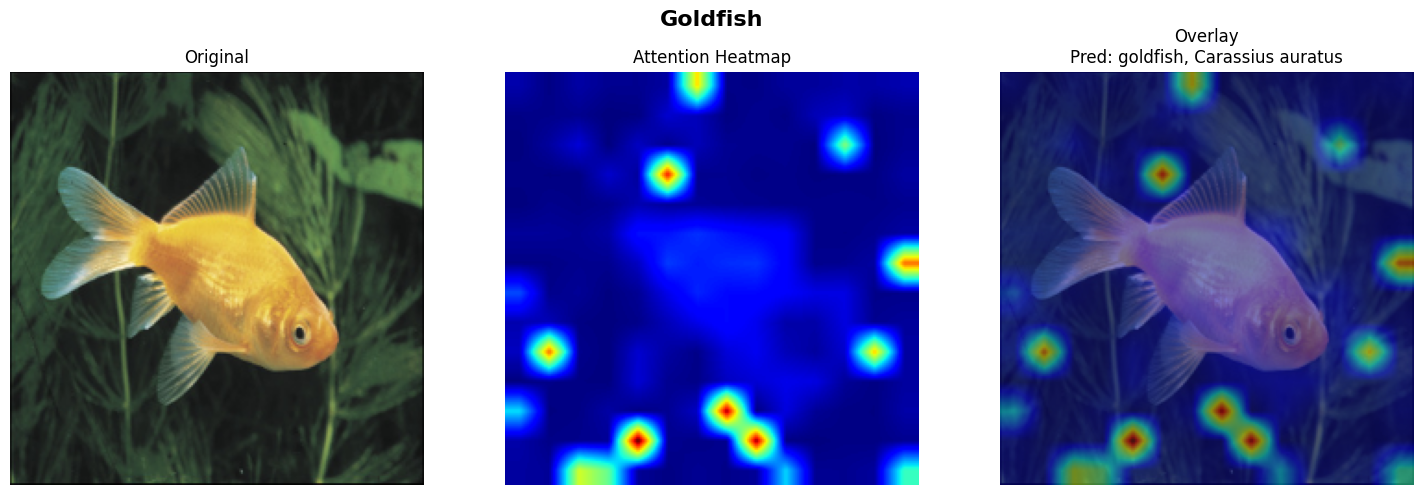

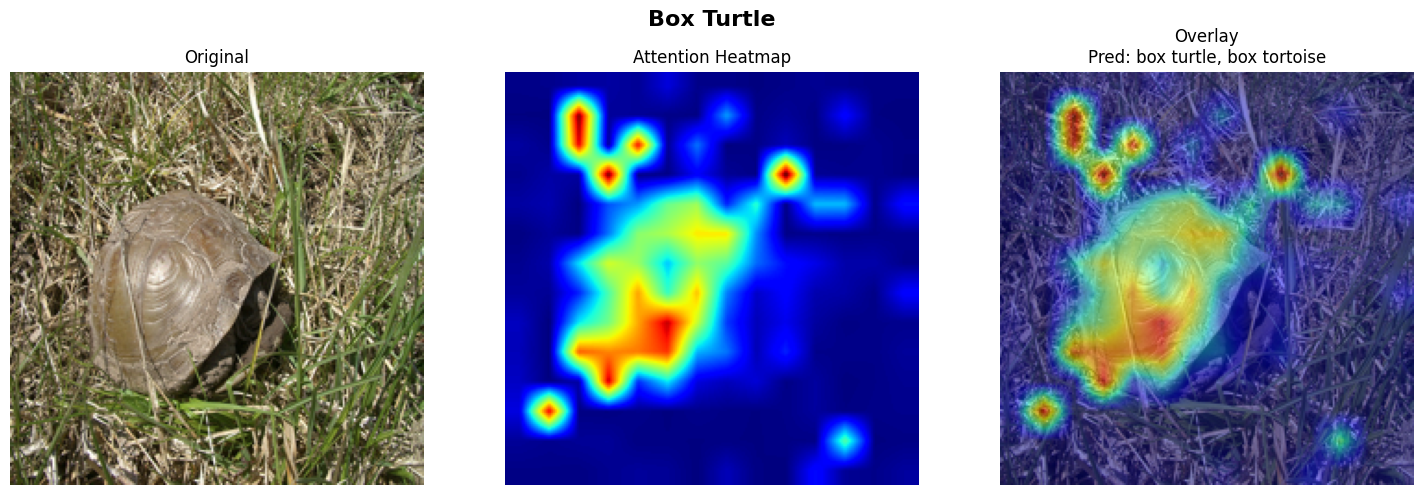

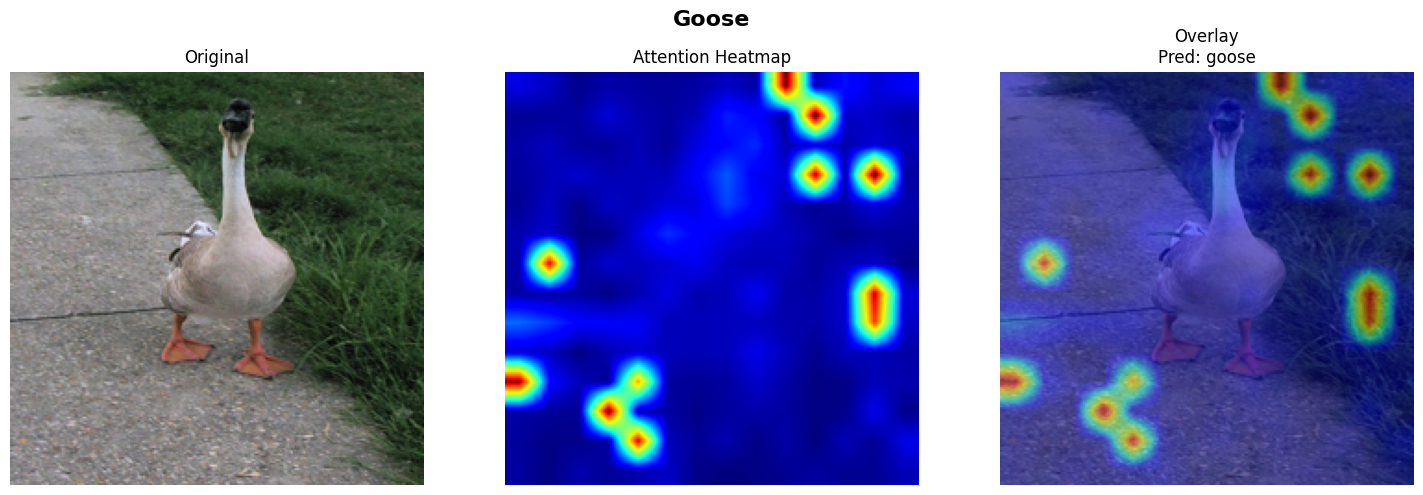

In [4]:
def visualize_attention(model, processor, img, title="Attention Map"):
    """
    Runs an image through a Vision Transformer, extracts the attention weights 
    from the final layer, and visualizes what the model was looking at.
    """
    # 1. FORWARD PASS
    # Set model to evaluation mode and process the image
    model.eval()
    with torch.no_grad():
        inputs = processor(images=img, return_tensors="pt")
        outputs = model(**inputs, output_attentions=True)

    # Extract the Top-1 predicted class label for our plot title
    predicted_class_idx = outputs.logits.argmax(-1).item()
    predicted_label = model.config.id2label[predicted_class_idx]

    # 2. EXTRACT AND AVERAGE ATTENTION WEIGHTS
    # The 'attentions' tuple contains matrices for all 12 layers. 
    # We select the final layer ([-1]) because it contains the most high-level, 
    # aggregated visual features right before the model makes its final prediction.
    # Shape: (batch_size, num_heads, seq_len, seq_len) -> (1, 12, 197, 197)
    final_layer_attn = outputs.attentions[-1]

    # The layer has multiple "heads" looking at different features. 
    # We average across all heads (dim=1) to get a unified consensus of where the model looked.
    # Shape becomes: (batch_size, seq_len, seq_len) -> (1, 197, 197)
    attn_avg = final_layer_attn.mean(dim=1)

    # 3. ISOLATE THE [CLS] TOKEN ATTENTION
    # The [CLS] token (index 0) acts as the overall image summary used for classification.
    # We extract how much attention this [CLS] token paid to the other 196 image patches (index 1 to 196).
    # Shape becomes: (num_patches,) -> (196,)
    cls_attn = attn_avg[0, 0, 1:]  

    # 4. RESHAPE TO SPATIAL GRID
    # We have 196 flat values. To map them back to the image, we reshape them into 
    # a 2D spatial grid (14x14).
    num_patches = cls_attn.shape[0]
    grid_size = int(num_patches ** 0.5)  # sqrt(196) = 14
    cls_attn_grid = cls_attn.reshape(grid_size, grid_size)

    # 5. UPSAMPLE AND NORMALIZE
    # The current heatmap is a tiny 14x14 grid. We use bilinear interpolation to 
    # smoothly scale it up to match our 224x224 image resolution.
    cls_attn_grid = cls_attn_grid.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, 14, 14) for interpolate
    attn_upsampled = F.interpolate(
        cls_attn_grid, size=(224, 224), mode="bilinear", align_corners=False
    )
    attn_upsampled = attn_upsampled.squeeze().numpy() # Remove extra dimensions

    # Normalize the heatmap values between 0.0 and 1.0 so matplotlib can render the colors properly
    attn_upsampled = (attn_upsampled - attn_upsampled.min()) / (attn_upsampled.max() - attn_upsampled.min() + 1e-8)

    # 6. VISUALIZATION
    # Resize the original image to 224x224 so it aligns perfectly with the heatmap overlay
    img_resized = img.resize((224, 224))

    # Create a 1x3 side-by-side plot layout
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Original Image
    axes[0].imshow(img_resized)
    axes[0].set_title("Original")
    axes[0].axis("off")

    # Plot 2: Just the Heatmap
    axes[1].imshow(attn_upsampled, cmap="jet")
    axes[1].set_title("Attention Heatmap")
    axes[1].axis("off")

    # Plot 3: Overlay (Image + Semi-transparent Heatmap)
    axes[2].imshow(img_resized)
    axes[2].imshow(attn_upsampled, cmap="jet", alpha=0.5)
    axes[2].set_title(f"Overlay\nPred: {predicted_label}")
    axes[2].axis("off")

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the visualization for all three images in our dictionary
for name, img in images.items():
    visualize_attention(model, processor, img, title=name)

## Patch-Masking Experiment:

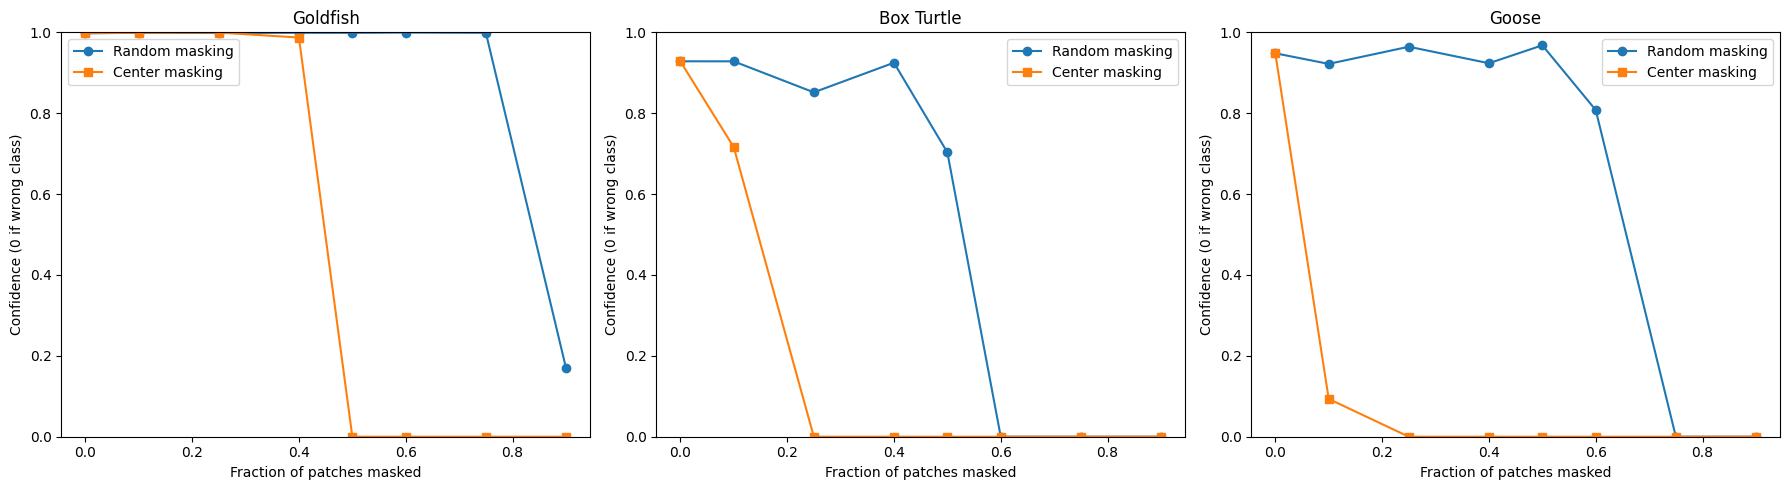


=== Goldfish ===
-- random masking --
  0% masked -> goldfish, Carassius auratus (0.998) ✓
  10% masked -> goldfish, Carassius auratus (0.999) ✓
  25% masked -> goldfish, Carassius auratus (0.998) ✓
  40% masked -> goldfish, Carassius auratus (0.999) ✓
  50% masked -> goldfish, Carassius auratus (0.999) ✓
  60% masked -> goldfish, Carassius auratus (0.999) ✓
  75% masked -> goldfish, Carassius auratus (0.999) ✓
  90% masked -> goldfish, Carassius auratus (0.170) ✓
-- center masking --
  0% masked -> goldfish, Carassius auratus (0.998) ✓
  10% masked -> goldfish, Carassius auratus (0.999) ✓
  25% masked -> goldfish, Carassius auratus (0.999) ✓
  40% masked -> goldfish, Carassius auratus (0.987) ✓
  50% masked -> toucan (0.045) X
  60% masked -> screen, CRT screen (0.034) X
  75% masked -> nematode, nematode worm, roundworm (0.085) X
  90% masked -> nematode, nematode worm, roundworm (0.095) X

=== Box Turtle ===
-- random masking --
  0% masked -> box turtle, box tortoise (0.928) ✓
  1

In [5]:
def mask_patches(img, patch_size=16, fraction=0.0, mode="random", seed=None):
    """
    Simulates occlusion by blacking out a specific fraction of the image.
    Because ViTs process images in distinct patches (16x16 pixels), we mask 
    entire patches rather than random individual pixels.
    """
    # 1. PREPARE THE IMAGE
    # ViTs require fixed dimensions. We ensure it is 224x224 and convert it to a NumPy 
    # array so we can easily manipulate pixel values.
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized).copy()

    # 2. CALCULATE GRID DIMENSIONS
    # A 224x224 image divided into 16x16 patches results in a 14x14 grid.
    # Total patches = 14 * 14 = 196 patches.
    grid_size = 224 // patch_size  
    num_patches = grid_size * grid_size  
    num_to_mask = int(fraction * num_patches)

    # If the fraction is 0, just return the original image untouched.
    if num_to_mask == 0:
        return Image.fromarray(img_array)

    # 3. DETERMINE WHICH PATCHES TO MASK
    if mode == "random":
        # Random masking tests how well the model handles general noise or partial occlusion.
        rng = np.random.default_rng(seed)
        patch_indices = rng.choice(num_patches, size=num_to_mask, replace=False)

    elif mode == "center":
        # ImageNet images are heavily center-biased (the subject is usually in the middle).
        # Center masking intentionally attacks the most important features first by ranking 
        # patches by their geometric distance from the center of the 14x14 grid.
        center = (grid_size - 1) / 2
        coords = [(r, c) for r in range(grid_size) for c in range(grid_size)]
        dists = [np.sqrt((r - center) ** 2 + (c - center) ** 2) for r, c in coords]
        order = np.argsort(dists)  # Sort indices: closest to center first
        patch_indices = order[:num_to_mask] # Select the 'num_to_mask' closest patches

    else:
        raise ValueError("mode must be 'random' or 'center'")

    # 4. APPLY THE MASK
    # Loop through the selected patches, calculate their pixel coordinates, and set them to 0 (black)
    for idx in patch_indices:
        # Convert 1D patch index back to 2D grid coordinates (row, col)
        r, c = idx // grid_size, idx % grid_size
        
        # Calculate bounding box pixel coordinates for this patch
        y0, y1 = r * patch_size, (r + 1) * patch_size
        x0, x1 = c * patch_size, (c + 1) * patch_size
        
        # Black out the patch across all color channels
        img_array[y0:y1, x0:x1] = 0  

    return Image.fromarray(img_array)


def evaluate_masking(model, processor, img, true_label_substring, mode="random", fractions=None, seed=0):
    """
    Evaluates how the model's confidence and accuracy degrade as more of the image is removed.
    """
    if fractions is None:
        fractions = [0.0, 0.1, 0.25, 0.4, 0.5, 0.6, 0.75, 0.9]

    results = []
    model.eval()
    
    # Test the model at every specified level of occlusion
    for frac in fractions:
        masked_img = mask_patches(img, fraction=frac, mode=mode, seed=seed)
        
        with torch.no_grad():
            inputs = processor(images=masked_img, return_tensors="pt")
            outputs = model(**inputs)
            
            # Convert raw logits to probabilities (0.0 to 1.0) using Softmax
            probs = outputs.logits.softmax(-1)
            
            # Extract the Top-1 prediction and its confidence score
            top_idx = probs.argmax(-1).item()
            top_label = model.config.id2label[top_idx]
            top_conf = probs[0, top_idx].item()
            
            # Check if the prediction is correct. 
            # We use substring matching because ImageNet labels often have multiple 
            # synonyms (e.g., "box turtle, box tortoise").
            correct = true_label_substring.lower() in top_label.lower()

        results.append({
            "fraction": frac,
            "predicted": top_label,
            "confidence": top_conf,
            "correct": correct
        })
    return results


# 1. SETUP EXPERIMENT DATA
# Define substrings that definitively prove the model got the core concept right
ground_truth = {
    "Goldfish": "goldfish",
    "Box Turtle": "box turtle",
    "Goose": "goose"
}

# The percentages of the image we will delete (0% up to 90%)
fractions = [0.0, 0.1, 0.25, 0.4, 0.5, 0.6, 0.75, 0.9]

# 2. RUN EXPERIMENT
all_results = {}
for name, img in images.items():
    all_results[name] = {
        "random": evaluate_masking(model, processor, img, ground_truth[name], mode="random", fractions=fractions),
        "center": evaluate_masking(model, processor, img, ground_truth[name], mode="center", fractions=fractions),
    }

# 3. PLOT RESULTS
# Create a line graph comparing how Random vs. Center occlusion affects confidence
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, all_results.items()):
    
    # We penalize wrong predictions by forcing their confidence to 0 in the plot.
    # This prevents the graph from looking deceptively confident if it strongly predicts the wrong thing.
    random_conf = [r["confidence"] if r["correct"] else 0 for r in res["random"]]
    center_conf = [r["confidence"] if r["correct"] else 0 for r in res["center"]]
    
    ax.plot(fractions, random_conf, marker="o", label="Random masking")
    ax.plot(fractions, center_conf, marker="s", label="Center masking")
    
    ax.set_title(name)
    ax.set_xlabel("Fraction of patches masked")
    ax.set_ylabel("Confidence (0 if wrong class)")
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 4. PRINT RAW DATA LOGS
for name, res in all_results.items():
    print(f"\n=== {name} ===")
    for mode in ["random", "center"]:
        print(f"-- {mode} masking --")
        for r in res[mode]:
            status = "✓" if r["correct"] else "X"
            print(f"  {r['fraction']*100:.0f}% masked -> {r['predicted']} ({r['confidence']:.3f}) {status}")

## CLS Token vs. Mean-Pooled Patch Tokens:

In [6]:
# ---------------------------------------------------------
# 1. Reload model + processor
# ---------------------------------------------------------
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name, use_fast=True)
model = AutoModelForImageClassification.from_pretrained(model_name, output_attentions=True)
model.eval()

# Move model to GPU if available for faster feature extraction
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [ ]:
# ---------------------------------------------------------
# 2. Load the CIFAR-10 dataset & configure DataLoader
# ---------------------------------------------------------
print("Downloading/Loading full CIFAR-10 training set...")
cifar_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
class_names = cifar_train.classes  # ['airplane', 'automobile', 'bird', ...]

# Custom collate function to batch PIL images and let the Hugging Face 
# processor handle resizing (32x32 -> 224x224) and normalization in parallel
def collate_fn(batch):
    images = [item[0].convert("RGB") for item in batch]
    labels = [item[1] for item in batch]
    inputs = processor(images=images, return_tensors="pt")
    return inputs, torch.tensor(labels)

# Use a batch size of 32 (or 64 if your GPU has plenty of VRAM)
train_loader = DataLoader(cifar_train, batch_size=32, shuffle=False, collate_fn=collate_fn)

Downloading/Loading full CIFAR-10 training set...


100%|██████████| 170M/170M [28:54<00:00, 98.3kB/s]


In [8]:
# ---------------------------------------------------------
# 3. Feature extraction: CLS token vs mean-pooled patch tokens
# ---------------------------------------------------------
print(f"Extracting features across all {len(cifar_train)} images...")
cls_feats, mean_feats, all_labels = [], [], []

with torch.no_grad():
    for batch_idx, (inputs, batch_labels) in enumerate(train_loader):
        # Move inputs to the active device (GPU/CPU)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        outputs = model(**inputs, output_hidden_states=True)
        last_hidden = outputs.hidden_states[-1]  # Shape: (batch_size, 197, 768)

        # 1. CLS Token (Index 0)
        cls_batch = last_hidden[:, 0, :].cpu().numpy()
        
        # 2. Mean-Pooled Patch Tokens (Indices 1 to 196)
        patch_tokens = last_hidden[:, 1:, :]
        mean_batch = patch_tokens.mean(dim=1).cpu().numpy()

        cls_feats.append(cls_batch)
        mean_feats.append(mean_batch)
        all_labels.extend(batch_labels.numpy())

        if (batch_idx + 1) % 100 == 0 or (batch_idx + 1) == len(train_loader):
            print(f"  Processed {min((batch_idx + 1) * 32, len(cifar_train))}/{len(cifar_train)} images")

# Stack all batches into final 2D NumPy arrays
cls_feats = np.vstack(cls_feats)
mean_feats = np.vstack(mean_feats)
labels = np.array(all_labels)

print(f"\nCLS feature matrix shape:        {cls_feats.shape}")
print(f"Mean-pooled feature matrix shape: {mean_feats.shape}")

Extracting features across all 50000 images...
  Processed 3200/50000 images
  Processed 6400/50000 images
  Processed 9600/50000 images
  Processed 12800/50000 images
  Processed 16000/50000 images
  Processed 19200/50000 images
  Processed 22400/50000 images
  Processed 25600/50000 images
  Processed 28800/50000 images
  Processed 32000/50000 images
  Processed 35200/50000 images
  Processed 38400/50000 images
  Processed 41600/50000 images
  Processed 44800/50000 images
  Processed 48000/50000 images
  Processed 50000/50000 images

CLS feature matrix shape:        (50000, 768)
Mean-pooled feature matrix shape: (50000, 768)


In [9]:
# ---------------------------------------------------------
# 4. Train/test split (same split indices for fair comparison)
# ---------------------------------------------------------
indices = np.arange(len(labels))
train_idx, test_idx = train_test_split(
    indices, test_size=0.25, random_state=42, stratify=labels
)

X_cls_train, X_cls_test = cls_feats[train_idx], cls_feats[test_idx]
X_mean_train, X_mean_test = mean_feats[train_idx], mean_feats[test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

print(f"\nTrain size: {len(train_idx)}, Test size: {len(test_idx)}")


Train size: 37500, Test size: 12500


In [10]:
# ---------------------------------------------------------
# 5. Train linear probes (logistic regression)
# ---------------------------------------------------------
print("\nTraining CLS-token linear probe...")
probe_cls = LogisticRegression(max_iter=2000)
probe_cls.fit(X_cls_train, y_train)

print("Training mean-pooled linear probe...")
probe_mean = LogisticRegression(max_iter=2000)
probe_mean.fit(X_mean_train, y_train)


Training CLS-token linear probe...
Training mean-pooled linear probe...


LogisticRegression(max_iter=2000)

In [11]:
# ---------------------------------------------------------
# 6. Evaluate and compare
# ---------------------------------------------------------
pred_cls = probe_cls.predict(X_cls_test)
pred_mean = probe_mean.predict(X_mean_test)

acc_cls = accuracy_score(y_test, pred_cls)
acc_mean = accuracy_score(y_test, pred_mean)

print("\n===== RESULTS =====")
print(f"CLS-token linear probe accuracy:   {acc_cls:.4f}")
print(f"Mean-pooled linear probe accuracy: {acc_mean:.4f}")
print(f"Difference (CLS - Mean):           {acc_cls - acc_mean:+.4f}")


===== RESULTS =====
CLS-token linear probe accuracy:   0.9597
Mean-pooled linear probe accuracy: 0.9633
Difference (CLS - Mean):           -0.0036


In [12]:
# ---------------------------------------------------------
# 7. Per-class breakdown (optional, useful for discussion)
# ---------------------------------------------------------

print("\n--- CLS-token probe: per-class report ---")
print(classification_report(y_test, pred_cls))

print("\n--- Mean-pooled probe: per-class report ---")
print(classification_report(y_test, pred_mean))


--- CLS-token probe: per-class report ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1250
           1       0.98      0.96      0.97      1250
           2       0.97      0.96      0.97      1250
           3       0.90      0.90      0.90      1250
           4       0.96      0.97      0.97      1250
           5       0.92      0.93      0.93      1250
           6       0.98      0.97      0.97      1250
           7       0.97      0.97      0.97      1250
           8       0.98      0.98      0.98      1250
           9       0.96      0.98      0.97      1250

    accuracy                           0.96     12500
   macro avg       0.96      0.96      0.96     12500
weighted avg       0.96      0.96      0.96     12500


--- Mean-pooled probe: per-class report ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1250
           1       0.98      0.97      0.98 